In [32]:
!apt-get install -y xvfb scrot > /dev/null 2>&1
!pip install pyscreenshot pyvirtualdisplay pillow > /dev/null 2>&1

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from base64 import b64decode
from IPython.display import display, Javascript, Video
from google.colab.output import eval_js
from google.colab import files
from io import BytesIO
from pyvirtualdisplay import Display
from pyvirtualdisplay import Display
import pyscreenshot as ImageGrab
import time

Error Managing Virtual Display: 'Display' object has no attribute 'is_started'
Saved: screen.png


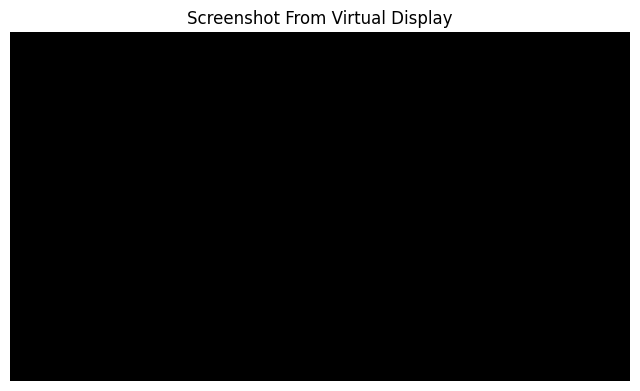

In [34]:
try:
    if 'vdisplay' not in globals() or not globals()['vdisplay'].is_started:
        vdisplay = Display(visible=0, size=(1920, 1080))
        vdisplay.start()
        print('Virtual Display Started.')
    else:
        print('Virtual Display Already Running.')

except Exception as e:
    print(f"Error Managing Virtual Display: {e}")

def capture_screen_screenshot(filename='screen.png'):

    img = ImageGrab.grab()
    img = np.array(img)

    if img is None or img.size == 0:
        raise ValueError('Screenshot Was Not Taken.')

    cv2.imwrite(filename, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    print('Saved:', filename)
    return filename, img

screenshot_path, frame = capture_screen_screenshot('screen.png')

plt.figure(figsize=(8, 6))
plt.imshow(frame)
plt.title('Screenshot From Virtual Display')
plt.axis('off')

plt.show()

Screenshot size: 1920 x 1080


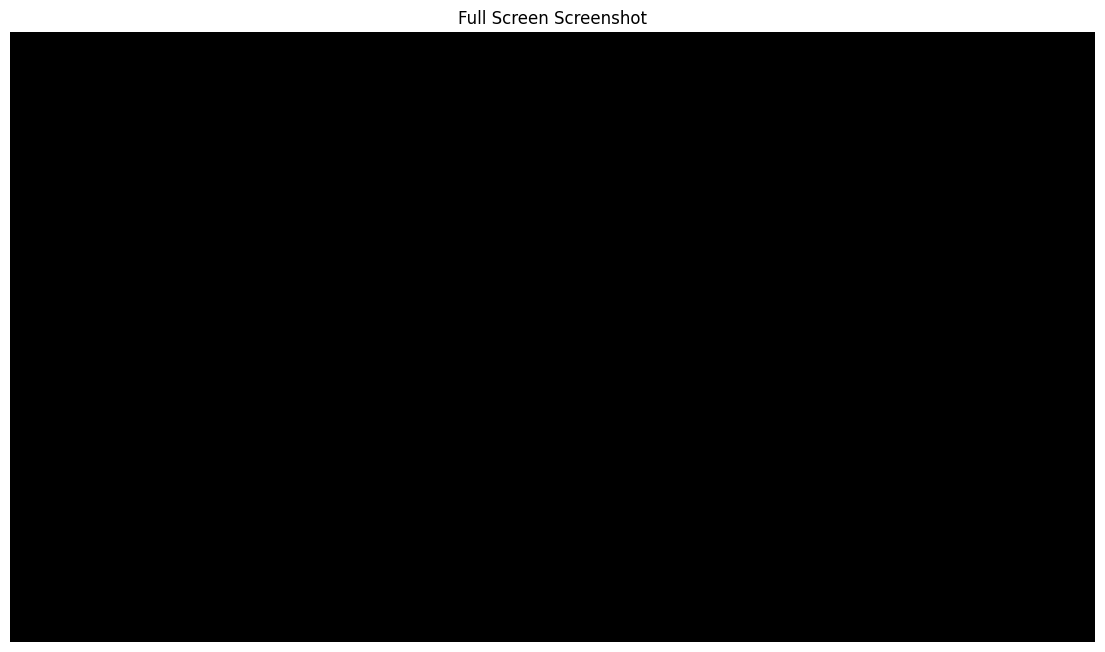

In [35]:
screen_pil = Image.open(screenshot_path)
screen_rgb = np.array(screen_pil.convert('RGB'))
screenshot_bgr = cv2.cvtColor(screen_rgb, cv2.COLOR_RGB2BGR)

print('Screenshot size:', screenshot_bgr.shape[1], 'x', screenshot_bgr.shape[0])

plt.figure(figsize=(14, 8))
plt.imshow(screenshot_bgr)
plt.title('Full Screen Screenshot')
plt.axis('off')

plt.show()

Saved: screen_region.jpg
Region shape: (500, 500, 3)


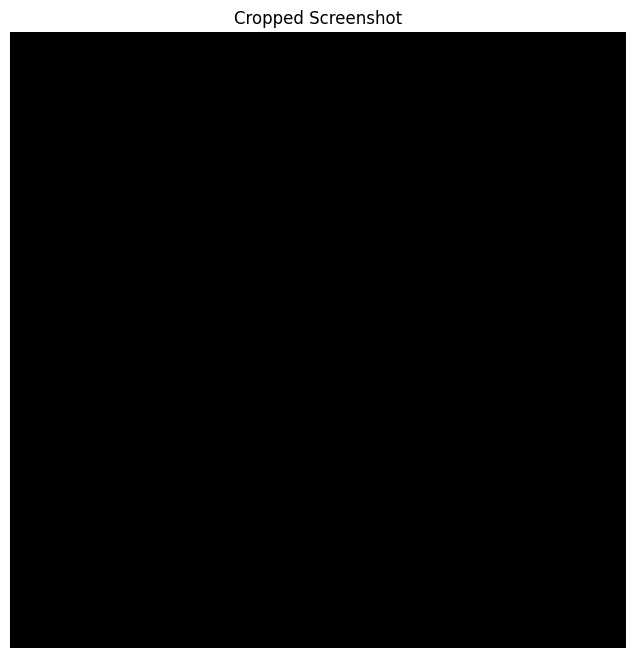

In [37]:
left, top, right, bottom = 500, 500, 1000, 1000

screen_height, screen_width = screen_rgb.shape[:2]
left = max(0, min(left, screen_width - 1))
top = max(0, min(top, screen_height - 1))
right = max(left + 1, min(right, screen_width))
bottom = max(top + 1, min(bottom, screen_height))

region_rgb = screen_rgb[top:bottom, left:right]
region_bgr = cv2.cvtColor(region_rgb, cv2.COLOR_RGB2BGR)
region_path = 'screen_region.jpg'
cv2.imwrite(region_path, region_bgr)

print('Saved:', region_path)
print('Region shape:', region_rgb.shape)

plt.figure(figsize=(14, 8))
plt.imshow(region_rgb)
plt.title('Cropped Screenshot')
plt.axis('off')

plt.show()

In [41]:
try:
    display
except NameError:
    display = Display(visible=0, size=(1920, 1080))
    display.start()

def record_screen_virtual(seconds=5, fps=5, filename='screen_record.mp4'):
    import pyscreenshot as ImageGrab

    frames = []
    interval = 1.0 / fps
    end_time = time.time() + seconds

    while time.time() < end_time:
        img = ImageGrab.grab()
        frame_rgb = np.array(img.convert('RGB'))
        frames.append(cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR))
        time.sleep(interval)

    if not frames:
        raise ValueError('No Frames Captured.')

    height, width = frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(filename, fourcc, fps, (width, height))
    for frame in frames:
        out.write(frame)
    out.release()

    print('Captured Frames:', len(frames))
    return filename

recorded_path = record_screen_virtual(seconds=5)

print('Saved:', recorded_path)

Captured Frames: 10
Saved: screen_record.mp4


In [42]:
Video(recorded_path, embed=True, width=900)

Sample frames: 1


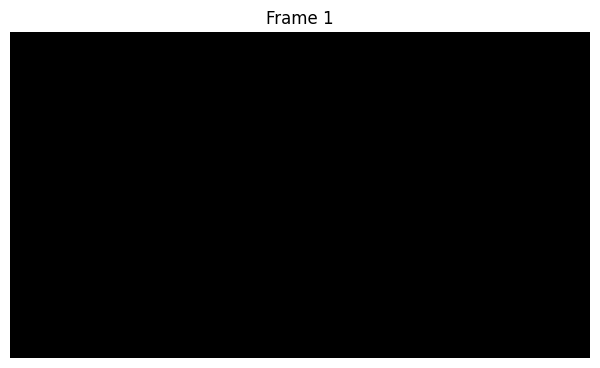

In [45]:
cap = cv2.VideoCapture(recorded_path)
recorded_frames = []
frame_index = 0

while cap.isOpened() and len(recorded_frames) < 6:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_index % 10 == 0:
      recorded_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    frame_index += 1

cap.release()
print('Sample frames:', len(recorded_frames))

plt.figure(figsize=(18, 9))
for i, frame in enumerate(recorded_frames, start=1):
    plt.subplot(2, 3, i)
    plt.imshow(frame)
    plt.title(f'Frame {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [46]:
files.download(screenshot_path)
files.download(region_path)
files.download(recorded_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>